In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score

from lincs_gsnn.utils.eval import filtered_rank
from lincs_gsnn.utils.aracne import (
    build_candidate_edges,
    load_expression_matrix,
    run_sample_pipeline,
)
from lincs_gsnn.utils.eval import eval_edge_inference

%reload_ext autoreload
%autoreload 2

np.random.seed(42)


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GSNN Edge Inference ARACNe-AP baseline (50-sample pipeline)

This notebook runs `ARACNe-AP` independently on each of the 50 trajectory samples, then averages the MI scores across samples and evaluates with AUROC / MRR.

Each sample goes through: load expression → stride-downsample → write ARACNe inputs → run ARACNe-AP (nobootstrap) → load MI scores. The per-sample scores are averaged to produce a single consensus edge score.

Expression is downsampled along the time axis with `TIME_STRIDE` (e.g. stride=10 keeps every 10th timepoint). Baseline subtraction is disabled by default — ARACNe relies on cross-sample variance in raw expression levels, and subtracting the t=0 baseline removes that signal.

> Note: ARACNe-AP is run in `--nobootstrap` mode with `--pvalue 1 --nobonferroni` and a dummy MI threshold of 0.0 so every gene pair receives a score.


In [2]:
N_SAMPLES = 50
TIME_STRIDE = 20 # ammount to downsample by ; 10 = 10x downsampled; time expensive with all data 

root_dir = Path('/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/default')
traj_dir = Path('/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output')
net_dir = root_dir / 'bionetwork'

aracne_root = Path('/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/aracne')
aracne_jar = Path('/home/exacloud/gscratch/mcweeney_lab/evans/ARACNe-AP/dist/aracne.jar')

data = torch.load(net_dir / 'bionetwork.pt', weights_only=False)
gene_names = pd.read_csv(traj_dir / 'predict_grid' / 'gene_names.csv')['gene_names'].astype(str).tolist()

print(f'N_SAMPLES: {N_SAMPLES}')
print(f'TIME_STRIDE: {TIME_STRIDE}')
print(f'aracne_jar: {aracne_jar}')


N_SAMPLES: 50
TIME_STRIDE: 20
aracne_jar: /home/exacloud/gscratch/mcweeney_lab/evans/ARACNe-AP/dist/aracne.jar


In [3]:
obs_meta = pd.read_csv(traj_dir / 'predict_grid' / 'pred_meta.csv')
obs_meta = obs_meta[lambda x: ~x.pert_id.isin(['BRD-K54997624'])] # same subset as OEI

res = build_candidate_edges(data, gene_names, net_dir)
regulators = pd.Series(sorted(res.source_gene.dropna().unique()))

print('# obs:', len(obs_meta))
print('# candidate edges:', len(res))
print('# regulators:', len(regulators))
print(res.groupby(['candidate', 'test_edge', 'train_edge']).size())


/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/aracne.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res[col] = res[col].fillna(False).astype(bool)
/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/aracne.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res[col] = res[col].fillna(False).astype(bool)
/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/aracne.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill 

# obs: 528
# candidate edges: 165113
# regulators: 169
candidate  test_edge  train_edge
True       False      False         164271
                      True             671
           True       False            171
dtype: int64


In [4]:
score_matrix = pd.DataFrame(index=res.index)

for sample_i in range(N_SAMPLES):
    print(f'[sample {sample_i:02d}/{N_SAMPLES}] running ARACNe...', end='\r')
    scores = run_sample_pipeline(
        sample_i=sample_i,
        traj_dir=traj_dir,
        obs_meta=obs_meta,
        gene_names=gene_names,
        regulators=regulators,
        aracne_root=aracne_root,
        aracne_jar=aracne_jar,
        res=res,
        stride=TIME_STRIDE,
    )
    score_matrix[f'sample_{sample_i}'] = scores.values

print(f'\nDone. score_matrix shape: {score_matrix.shape}')
score_matrix.head()


[sample 49/50] running ARACNe...
Done. score_matrix shape: (165113, 50)


,sample_0,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,...,sample_40,sample_41,sample_42,sample_43,sample_44,sample_45,sample_46,sample_47,sample_48,sample_49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.290777,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [5]:
res_cand = res.copy()
res_cand['score'] = score_matrix.mean(axis=1)

n_nonzero = (res_cand['score'] > 0).sum()
print(f'# candidate edges with nonzero avg MI: {n_nonzero} / {len(res_cand)}')


# candidate edges with nonzero avg MI: 43427 / 165113


In [6]:
perf_dict = eval_edge_inference(res_cand, data=data, metric='score')

/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn/lincs_gsnn/utils/eval.py:106: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res['in_tft'] = res['in_tft'].fillna(False).astype(bool)


In [7]:
perf_dict['train']

{'auroc': 0.5385900782178739,
 'aupr': 0.011662171154995567,
 'mrr': 0.05350351115177661,
 'top1_acc': 0.013412816691505217,
 'top10_acc': 0.12518628912071536,
 'top100_acc': 0.33084947839046197,
 'n': 671}

In [8]:
perf_dict['test']

{'auroc': 0.5805897173191097,
 'aupr': 0.006407666298015204,
 'mrr': 0.09191437803893722,
 'top1_acc': 0.03508771929824561,
 'top10_acc': 0.1871345029239766,
 'top100_acc': 0.39766081871345027,
 'n': 171}

In [9]:
perf_dict['test_tft']

{'auroc': 0.5077216139316846,
 'aupr': 0.02135351426152198,
 'mrr': 0.03355215205660244,
 'top1_acc': 0.004470938897168405,
 'top10_acc': 0.07948335817188276,
 'top100_acc': 0.2687531048186786,
 'n': 2013}

In [10]:
perf_dict['test_tft_isolate']

{'auroc': 0.49416058272708363,
 'aupr': 0.005541523276278502,
 'mrr': 0.03434292557689785,
 'top1_acc': 0.006237006237006237,
 'top10_acc': 0.08731808731808732,
 'top100_acc': 0.2203742203742204,
 'n': 481}

In [11]:
perf_dict['neg']

{'auroc': None,
 'aupr': None,
 'mrr': 0.02406053196292605,
 'top1_acc': 0.0,
 'top10_acc': 0.05424694005842547,
 'top100_acc': 0.2511802191571448,
 'n': 162258}

## Score distributions

In [12]:
metric = 'score'

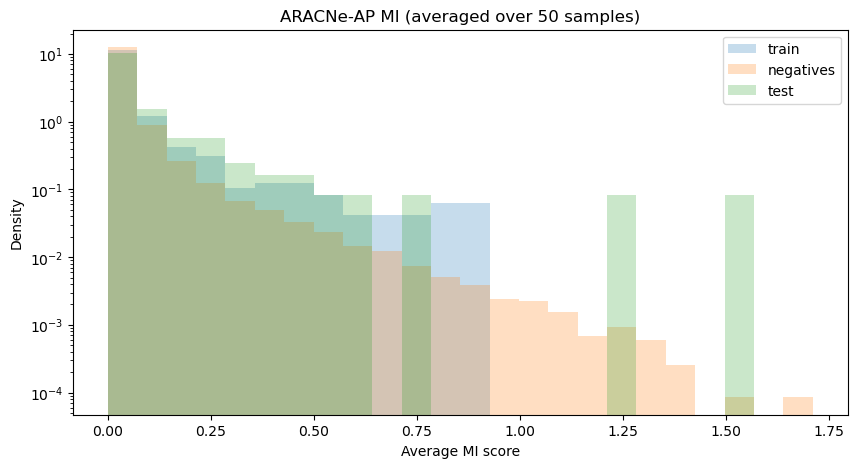

In [13]:
_bins = np.linspace(res_cand[metric].min(), res_cand[metric].max(), 25)

plt.figure(figsize=(10, 5))
plt.hist(res_cand[lambda x: x.train_edge][metric], bins=_bins, alpha=0.25, label='train', density=True)
plt.hist(res_cand[lambda x: x.negative][metric], bins=_bins, alpha=0.25, label='negatives', density=True)
plt.hist(res_cand[lambda x: x.test_edge][metric], bins=_bins, alpha=0.25, label='test', density=True)
plt.xlabel('Average MI score')
plt.ylabel('Density')
plt.title(f'ARACNe-AP MI (averaged over {N_SAMPLES} samples)')
plt.legend()
plt.yscale('log')
plt.show()


## Per-sample AUROC breakdown


Per-sample test AUROC: mean=0.5125, std=0.0092


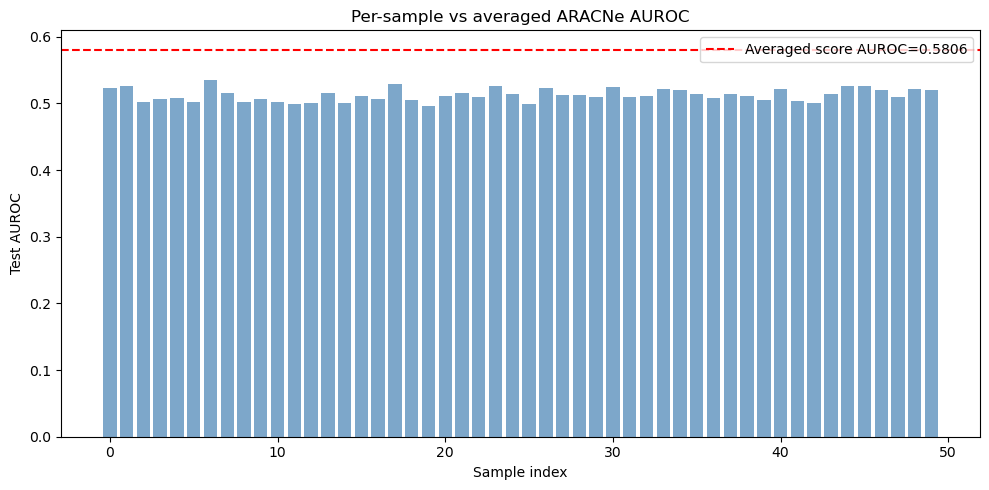

In [14]:
auroc_test = perf_dict['test']['auroc']

per_sample_auroc = []
for col in score_matrix.columns:
    y_true = res_cand[lambda x: ~x.train_edge]['test_edge'].values
    y_score = score_matrix.loc[res_cand[lambda x: ~x.train_edge].index, col].values
    per_sample_auroc.append(roc_auc_score(y_true, y_score))

per_sample_auroc = np.array(per_sample_auroc)
print(f'Per-sample test AUROC: mean={per_sample_auroc.mean():.4f}, std={per_sample_auroc.std():.4f}')

plt.figure(figsize=(10, 5))
plt.bar(range(N_SAMPLES), per_sample_auroc, color='steelblue', alpha=0.7)
plt.axhline(auroc_test, color='red', ls='--', label=f'Averaged score AUROC={auroc_test:.4f}')
plt.xlabel('Sample index')
plt.ylabel('Test AUROC')
plt.title('Per-sample vs averaged ARACNe AUROC')
plt.legend()
plt.tight_layout()
plt.show()
